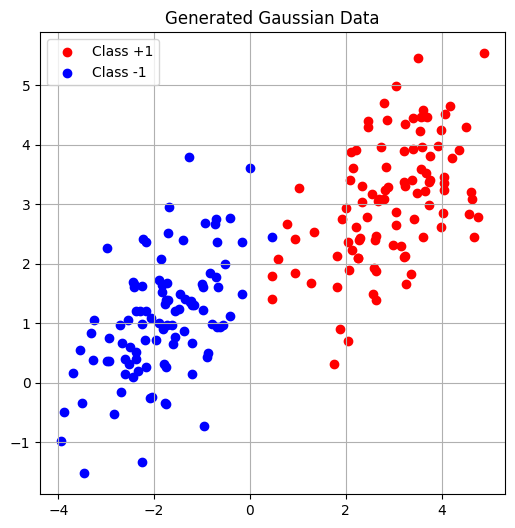

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 2 sınıflı 2B (2 boyutlu) Gauss dağılımlı veri üretimi
np.random.seed(0)  # Rastgelelik sabitleniyor; her çalıştırmada aynı veri elde edilir

n_samples = 100  # Her sınıf için 100 örnek (toplam 200 veri noktası)
mean1 = [3, 3]   # 1. sınıfın ortalaması (x, y)
mean2 = [-2, 1] # 2. sınıfın ortalaması (x, y)
cov = [[1, 0.5], [0.5, 1]]  # Kovaryans matrisi (2x2): x ve y arasındaki ilişkiyi gösterir

# Her biri (100 x 2) boyutunda iki sınıf verisi üretiliyor
X1 = np.random.multivariate_normal(mean1, cov, n_samples)  # Sınıf +1 verileri
X2 = np.random.multivariate_normal(mean2, cov, n_samples)  # Sınıf -1 verileri

# Sınıf etiketleri: +1 ve -1
y1 = np.ones(n_samples)       # (100,)
y2 = -np.ones(n_samples)      # (100,)

# İki sınıf birleştiriliyor
X = np.vstack((X1, X2))       # (200 x 2): tüm örnekler bir arada
y = np.hstack((y1, y2))       # (200,): etiket vektörü

# 📊 Veriyi görselleştir
plt.figure(figsize=(6,6))
plt.scatter(X1[:,0], X1[:,1], c='r', label='Class +1')
plt.scatter(X2[:,0], X2[:,1], c='b', label='Class -1')
plt.title("Generated Gaussian Data")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
#  Manuel numpy fonksiyonları ile model oluşturup eğitme

# Her epoch sonunda kayıp değerlerini izlemek için global listeler tanımlanıyor.
global losses_manuel
losses_manuel=[]

# Perceptron eğitim algoritması (manuel uygulama)
def perceptron_train(X, y, lr=0.1, epochs=10):
    """
    X: (n x d) boyutunda giriş matrisi
    y: (n,) boyutunda etiket vektörü (+1 veya -1)
    lr: öğrenme oranı
    epochs: tüm veri üzerinden kaç kez geçileceği
    """
    n, d = X.shape              # n=200 (örnek sayısı), d=2 (özellik sayısı)
    w = np.random.rand(2)       # Ağırlık vektörü (2,)
    b = np.random.rand()        # Bias (skaler)
    for epoch in range(epochs):  # Her epoch: tüm veriler bir kez işlenir
        sample_losses = []       # Bu epoch içindeki her örneğin kaybını tutar
        for i in range(n):       # Her örnek üzerinde sırayla gezin
            # Tahmin edilen doğrusal skor: y_i * (w·x_i + b)
            # Bu değer ≤ 0 ise, örnek yanlış sınıflandırılmıştır
            loss = y[i] * (np.dot(w, X[i]) + b)
            if loss <= 0:
                # Ağırlıkları güncelle (Stochastic Gradient Descent - tek örnekle)
                w += lr * y[i] * X[i]   # w: (2,), X[i]: (2,)
                b += lr * y[i]          # b: skaler
                sample_losses.append(-loss)
            else:
                sample_losses.append(0) # Doğru sınıflandırma durumunda loss=0
        # Epoch ortalama kaybı kaydet sonra çizdirmek için
        losses_manuel.append(sum(sample_losses)/len(sample_losses))
        # Her epoch sonunda çıktıyı yazdır
        print(f"Epoch {epoch}: Loss = {sum(sample_losses)/len(sample_losses):.4f}")
        print(f"Epoch {epoch}: Weight Matrix = {w}")
        print(f"Epoch {epoch}: Bias Value = {b:.4f}")
    return w, b

# Eğitim işlemini başlat
w, b = perceptron_train(X, y, lr=0.1, epochs=10)

Epoch 0: Loss = 0.0046
Epoch 0: Weight Matrix = [ 1.04195624 -0.37554887]
Epoch 0: Bias Value = -0.1173
Epoch 1: Loss = 0.0033
Epoch 1: Weight Matrix = [ 1.09868745 -0.29247766]
Epoch 1: Bias Value = -0.1173
Epoch 2: Loss = 0.0026
Epoch 2: Weight Matrix = [ 1.12854364 -0.27078187]
Epoch 2: Bias Value = -0.1173
Epoch 3: Loss = 0.0019
Epoch 3: Weight Matrix = [ 1.1415233  -0.30750004]
Epoch 3: Bias Value = -0.1173
Epoch 4: Loss = 0.0026
Epoch 4: Weight Matrix = [ 1.17137949 -0.28580426]
Epoch 4: Bias Value = -0.1173
Epoch 5: Loss = 0.0019
Epoch 5: Weight Matrix = [ 1.18435915 -0.32252243]
Epoch 5: Bias Value = -0.1173
Epoch 6: Loss = 0.0025
Epoch 6: Weight Matrix = [ 1.21421533 -0.30082664]
Epoch 6: Bias Value = -0.1173
Epoch 7: Loss = 0.0018
Epoch 7: Weight Matrix = [ 1.227195   -0.33754482]
Epoch 7: Bias Value = -0.1173
Epoch 8: Loss = 0.0025
Epoch 8: Weight Matrix = [ 1.25705118 -0.31584903]
Epoch 8: Bias Value = -0.1173
Epoch 9: Loss = 0.0018
Epoch 9: Weight Matrix = [ 1.27003084 -0.

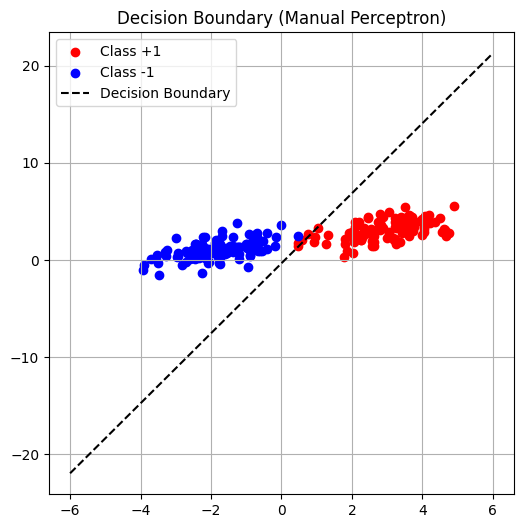

In [6]:
# Karar sınırını (decision boundary) çiz
x_vals = np.linspace(-6, 6, 100)   # X ekseni için 100 nokta (1D vektör)
# Karar sınırı denklemi: w0*x + w1*y + b = 0  →  y = -(w0*x + b)/w1
y_vals = -(w[0]*x_vals + b) / w[1]

plt.figure(figsize=(6,6))
plt.scatter(X1[:,0], X1[:,1], c='r', label='Class +1')
plt.scatter(X2[:,0], X2[:,1], c='b', label='Class -1')
plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')
plt.title("Decision Boundary (Manual Perceptron)")
plt.legend()
plt.grid(True)
plt.show()

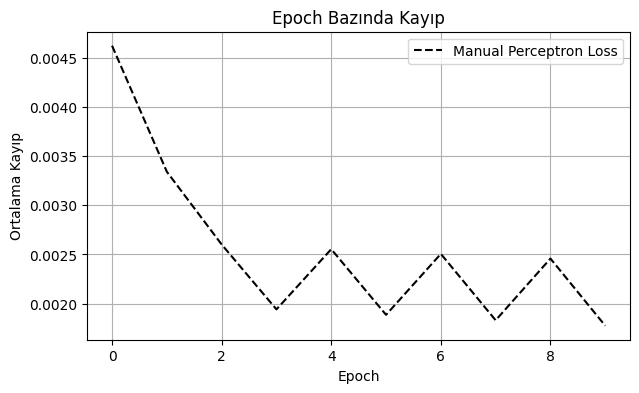

In [7]:
# Modelin epoch bazında kayıplarını çiz
plt.figure(figsize=(7,4))
plt.plot(losses_manuel, 'k--', label='Manual Perceptron Loss')
plt.title("Epoch Bazında Kayıp")
plt.xlabel("Epoch")
plt.ylabel("Ortalama Kayıp")
plt.legend()
plt.grid(True)
plt.show()